In [29]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import copy
import glob
import os
import warnings
warnings.simplefilter("ignore")
import matplotlib.pyplot as plt

import torch
import signatory
from scipy.linalg import pinv
from collections import deque
import time
from hmmlearn.hmm import GaussianHMM

import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
LEVELS = 20
# DISTANCES = np.array([0,0.0005,0.001,0.002,0.003])
DISTANCES = np.array([0,2,4,8,16,32])

HORIZON = 5
N_REGIMES = 3

GAMMA = 0.1     # inventory risk aversion
KAPPA = 1.5     # order arrival intensity

### Synthtic Data

In [4]:
def generate_synthetic_lob(n_steps=500):

    book=[]
    mid=100

    for t in range(n_steps):

        mid += np.random.normal(0,0.02)

        bid_prices = mid - np.arange(1,LEVELS+1)*0.01
        ask_prices = mid + np.arange(1,LEVELS+1)*0.01

        bid_vol = np.random.randint(50,1000,LEVELS)
        ask_vol = np.random.randint(50,1000,LEVELS)

        book.append({
            "bid_prices":bid_prices,
            "ask_prices":ask_prices,
            "bid_vol":bid_vol,
            "ask_vol":ask_vol
        })

    return book

### Read data and convert to the form

In [6]:
def read_pq(date: str,full = False, instrument: str | None = None,  exc: str | None = None):
    # read all the parquet file downloaded
    root = f"C:/GIT/market_game/market_data/NIFTY_FUT/2026-{date}"

    all_files = glob.glob(
        "**/*.parquet",
        root_dir=root,
        recursive=True
    )

    df = pd.DataFrame()
    
    i = 1
    
    #club all the files into a single one
    for file_name in all_files:
        try:
            if instrument is None:
                _df = pd.read_parquet(os.path.join(root, file_name))
            else:
                _df = pd.read_parquet(os.path.join(root, file_name))
                _df = _df[_df['security_id'] == instrument]
        except:
            continue
        
        df = pd.concat([df, _df], axis= 0)
    
    '''
    compute the mid price and 
    normalize the price so that we are concerned of only the distance from centre
    '''
    if full:
        
        __ask = df[df["side"] == "Ask"].groupby("snap_idx")["price"].min()
        __bid = df[df["side"] == "Bid"].groupby("snap_idx")["price"].max()
        __mid = 0.5*(__ask + __bid)

        df = df.reset_index(drop = True)
        df["price_norm"] = df["price"] - df["snap_idx"].map(__mid)
        
        # considering only NIFTY future with lot = 65
        if exc == 'fno':
            df["qty_norm"] = df["qty"] / 65 
        else:
            df["qty_norm"] = df["qty"]  
        
        return df, __mid
    else:
        return df, None
        

In [7]:
full= True
df_market, mid_price = read_pq('02-27', full, '51714', 'fno')

In [9]:
def dataframe_to_snapshots(df):

    snapshots=[]

    for snap,group in df.groupby("snap_idx"):

        bid = group[group.side=="Bid"].sort_values("price",ascending=False)
        ask = group[group.side=="Ask"].sort_values("price")

        snapshots.append({

            "bid_prices":bid.price.values[:LEVELS],
            "bid_vol":bid.qty.values[:LEVELS],

            "ask_prices":ask.price.values[:LEVELS],
            "ask_vol":ask.qty.values[:LEVELS]

        })

    return snapshots

In [10]:
data = dataframe_to_snapshots(df_market)

### Feature Extraction

In [12]:
def compute_features(book):

    feats=[]

    for snap in book:

        bid=snap["bid_prices"]
        ask=snap["ask_prices"]

        mid=(bid[0]+ask[0])/2
        spread=ask[0]-bid[0]

        bid_vol=sum(snap["bid_vol"][:5])
        ask_vol=sum(snap["ask_vol"][:5])

        imbalance=(bid_vol-ask_vol)/(bid_vol+ask_vol+1e-8)

        feats.append([mid,spread,bid_vol,ask_vol,imbalance])

    return np.array(feats)

### Regimes
0 → low volatility <br>
1 → high volatility <br>
2 → liquidity imbalance

In [13]:
def detect_regimes(book):

    feats = compute_features(book)
    model = KMeans(n_clusters=N_REGIMES)
    regimes = model.fit_predict(feats)
    return regimes

<Axes: >

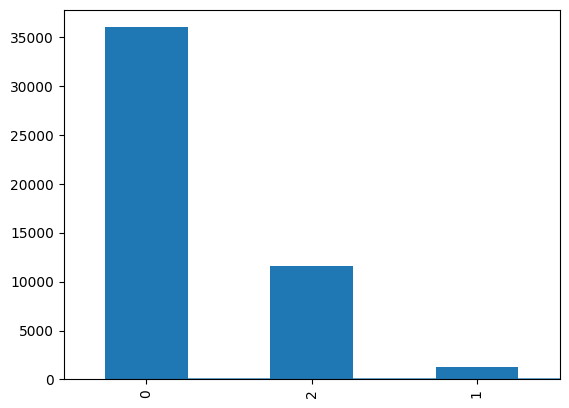

In [20]:
regimes = detect_regimes(data)
pd.Series(regimes)[0:500].plot()
pd.Series(regimes).value_counts().plot(kind='bar')

### Execution Probability

In [21]:
def compute_fill_probabilities(book,regimes):

    regime_probs={}

    for r in np.unique(regimes):

        regime_probs[r]={"bid":[],"ask":[]}

        idx=np.where(regimes==r)[0]

        for d in DISTANCES:

            bid_fills=[]
            ask_fills=[]

            for t in idx:

                if t+HORIZON>=len(book):
                    continue

                snap=book[t]

                bid=snap["bid_prices"]
                ask=snap["ask_prices"]

                mid=(bid[0]+ask[0])/2

                bid_price=mid*(1-d)
                ask_price=mid*(1+d)

                bid_fill=0
                ask_fill=0

                for k in range(1,HORIZON):

                    future=book[t+k]

                    if future["bid_prices"][0] >= bid_price:
                        bid_fill=1

                    if future["ask_prices"][0] <= ask_price:
                        ask_fill=1

                bid_fills.append(bid_fill)
                ask_fills.append(ask_fill)

            regime_probs[r]["bid"].append(np.mean(bid_fills))
            regime_probs[r]["ask"].append(np.mean(ask_fills))

    return regime_probs

In [23]:
pd.DataFrame(compute_fill_probabilities(data,regimes))

,0,1,2
bid,"[0.06960460140598516, 1.0, 1.0, 1.0, 1.0]","[0.05075337034099921, 1.0, 1.0, 1.0, 1.0]","[0.0769627211819275, 1.0, 1.0, 1.0, 1.0]"
ask,"[0.08730445413876463, 1.0, 1.0, 1.0, 1.0]","[0.09357652656621729, 1.0, 1.0, 1.0, 1.0]","[0.0738704689915822, 1.0, 1.0, 1.0, 1.0]"


In [24]:
def avellaneda_stoikov_quotes(mid,inventory):

    delta = (1/GAMMA) * np.log(1 + GAMMA/KAPPA)

    bid = mid - delta - GAMMA*inventory
    ask = mid + delta - GAMMA*inventory

    return bid,ask

In [25]:
def optimal_quotes(book,regimes,regime_probs,inventory=0):

    snap=book[-1]

    bid=snap["bid_prices"]
    ask=snap["ask_prices"]

    mid=(bid[0]+ask[0])/2
    spread=ask[0]-bid[0]

    regime=regimes[-1]

    bid_probs=regime_probs[regime]["bid"]
    ask_probs=regime_probs[regime]["ask"]

    best_bid=None
    best_ask=None

    best_val=-1

    for d,p in zip(DISTANCES,bid_probs):

        val = p*(spread/2 - d)

        if val>best_val:
            best_val=val
            best_bid=d

    best_val=-1

    for d,p in zip(DISTANCES,ask_probs):

        val = p*(spread/2 - d)

        if val>best_val:
            best_val=val
            best_ask=d

    bid_quote = mid*(1-best_bid)
    ask_quote = mid*(1+best_ask)

    return bid_quote,ask_quote

In [26]:
def run_market_maker(book,inventory=0):

    regimes = detect_regimes(book)

    regime_probs = compute_fill_probabilities(book,regimes)

    bid_quote,ask_quote = optimal_quotes(
        book,
        regimes,
        regime_probs,
        inventory
    )

    return bid_quote,ask_quote,regimes,regime_probs

In [27]:
if __name__=="__main__":

    book = generate_synthetic_lob(1000)

    bid,ask,regimes,probs = run_market_maker(book)

    print("Recommended Quotes")
    print("Bid:",bid)
    print("Ask:",ask)

    print("\nFill probability curves")

    for r,data in probs.items():

        print("Regime",r)
        print("Distances",DISTANCES)
        print("Bid probs",data["bid"])
        print("Ask probs",data["ask"])

Recommended Quotes
Bid: 98.90133727521156
Ask: 99.00028808789311

Fill probability curves
Regime 0
Distances [0.     0.0005 0.001  0.002  0.003 ]
Bid probs [np.float64(0.550531914893617), np.float64(0.9813829787234043), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Ask probs [np.float64(0.6196808510638298), np.float64(0.9973404255319149), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Regime 1
Distances [0.     0.0005 0.001  0.002  0.003 ]
Bid probs [np.float64(0.526984126984127), np.float64(0.9936507936507937), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Ask probs [np.float64(0.6253968253968254), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Regime 2
Distances [0.     0.0005 0.001  0.002  0.003 ]
Bid probs [np.float64(0.5921052631578947), np.float64(0.9967105263157895), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Ask probs [np.float64(0.5657894736842105), np.float64(0.9835526315789473), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


### Visualisation

In [30]:
def plot_lob_heatmap(book,levels=20):

    bids=[]
    asks=[]

    for snap in book:

        bids.append(snap["bid_vol"][:levels])
        asks.append(snap["ask_vol"][:levels])

    bids=np.array(bids)
    asks=np.array(asks)

    fig,ax=plt.subplots(1,2,figsize=(14,5))

    sns.heatmap(bids.T,cmap="Blues",ax=ax[0])
    ax[0].set_title("Bid Depth Heatmap")
    ax[0].set_xlabel("Time")
    ax[0].set_ylabel("Bid Level")

    sns.heatmap(asks.T,cmap="Reds",ax=ax[1])
    ax[1].set_title("Ask Depth Heatmap")
    ax[1].set_xlabel("Time")

    plt.show()

In [31]:
def plot_imbalance(book):

    imbalance=[]

    for snap in book:

        bid=sum(snap["bid_vol"][:5])
        ask=sum(snap["ask_vol"][:5])

        imb=(bid-ask)/(bid+ask+1e-8)

        imbalance.append(imb)

    plt.figure(figsize=(10,4))

    plt.plot(imbalance)
    plt.title("Order Book Imbalance")
    plt.xlabel("Time")
    plt.ylabel("Imbalance")

    plt.axhline(0,color="black")

    plt.show()

In [32]:
def plot_regimes(book,regimes):

    mid_prices=[]

    for snap in book:

        bid=snap["bid_prices"][0]
        ask=snap["ask_prices"][0]

        mid=(bid+ask)/2

        mid_prices.append(mid)

    plt.figure(figsize=(12,4))

    plt.scatter(range(len(mid_prices)),
                mid_prices,
                c=regimes,
                cmap="viridis",
                s=5)

    plt.title("Market Regimes Over Time")
    plt.xlabel("Time")
    plt.ylabel("Mid Price")

    plt.show()

In [34]:
def plot_fill_probabilities(distances,probs):

    plt.figure(figsize=(6,4))

    plt.plot(distances,probs["bid"],label="Bid Fill")
    plt.plot(distances,probs["ask"],label="Ask Fill")

    plt.xlabel("Distance from Mid")
    plt.ylabel("Fill Probability")

    plt.title("Execution Probability Curve")

    plt.legend()

    plt.show()

In [35]:
def plot_fill_surface(distances,regime_probs):

    data=[]

    for r,val in regime_probs.items():

        for d,p in zip(distances,val["bid"]):

            data.append([r,d,p])

    df=pd.DataFrame(data,
        columns=["regime","distance","prob"])

    pivot=df.pivot(index="regime",
                   columns="distance",
                   values="prob")

    sns.heatmap(pivot,cmap="viridis")

    plt.title("Fill Probability Surface (Bid)")

    plt.show()

In [36]:
def plot_quotes(book,bid_quote,ask_quote):

    mids=[]

    for snap in book:

        bid=snap["bid_prices"][0]
        ask=snap["ask_prices"][0]

        mids.append((bid+ask)/2)

    plt.figure(figsize=(10,4))

    plt.plot(mids,label="Mid Price")

    plt.axhline(bid_quote,color="green",label="Optimal Bid")
    plt.axhline(ask_quote,color="red",label="Optimal Ask")

    plt.legend()

    plt.title("Market Making Quotes")

    plt.show()

In [37]:
def run_visual_analysis(book,regimes,regime_probs,distances):

    plot_lob_heatmap(book)

    plot_imbalance(book)

    plot_regimes(book,regimes)

    for r in regime_probs:

        plot_fill_probabilities(
            distances,
            regime_probs[r]
        )

    plot_fill_surface(distances,regime_probs)

In [48]:
pd.Series(regimes).value_counts()

0    35882
2    11752
1     1263
Name: count, dtype: int64

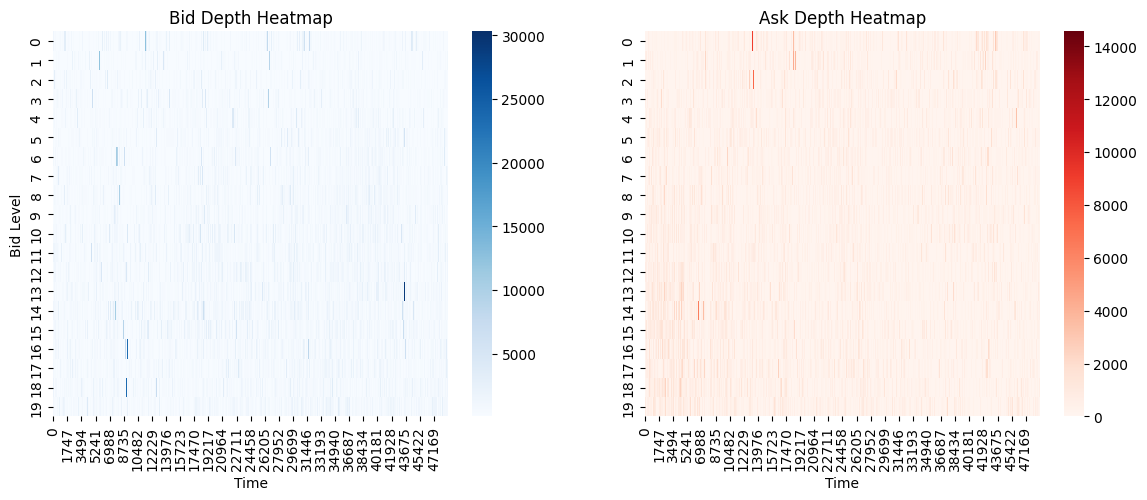

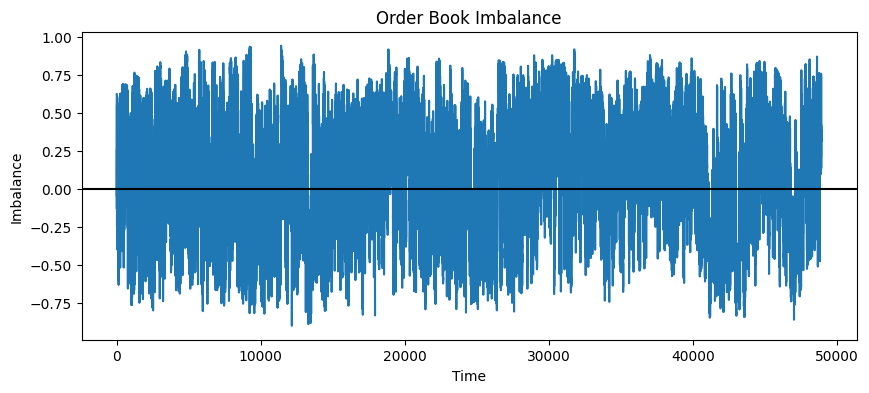

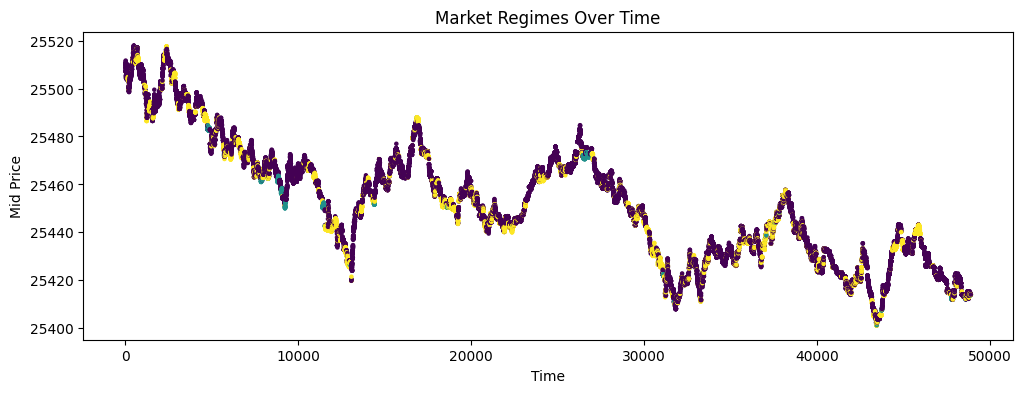

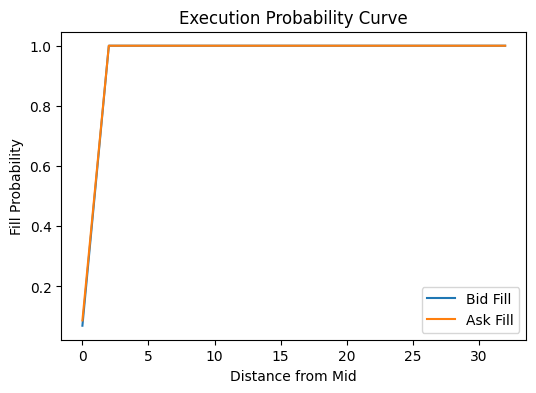

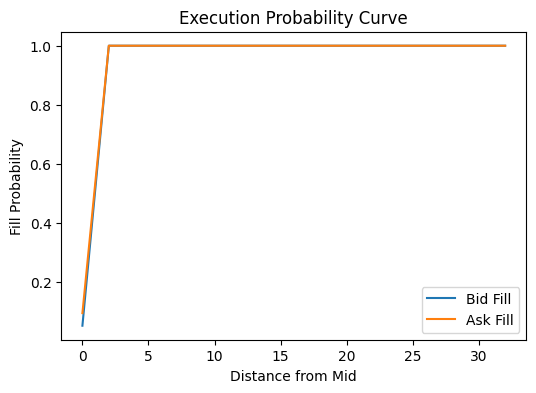

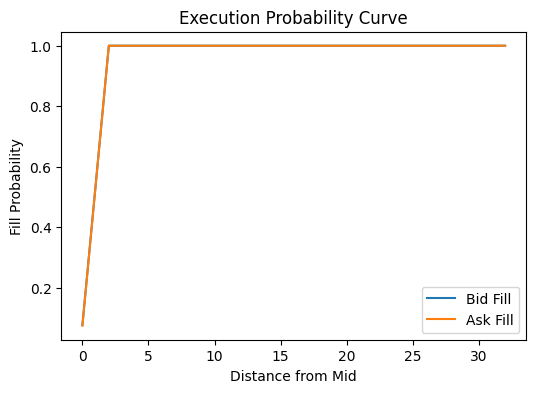

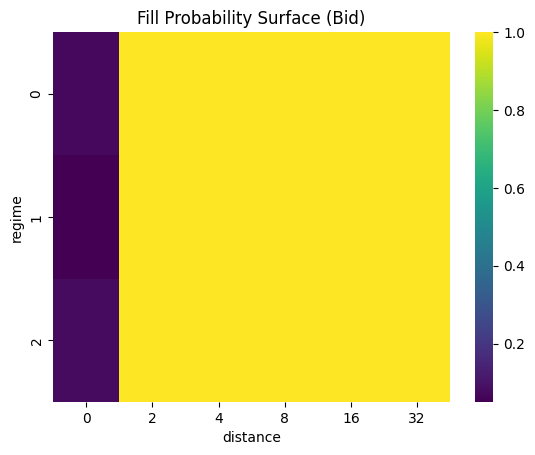

In [45]:
# book = dataframe_to_snapshots(df_market)

# regimes, probs, quotes = run_market_maker(book)

bid_quote,ask_quote,regimes,regime_probs = run_market_maker(book)

run_visual_analysis(book, regimes, regime_probs, DISTANCES)

In [59]:
def estimate_queue_depletion(df):

    depletion = []

    snapshots = sorted(df.snap_idx.unique())

    for i in range(len(snapshots)-1):

        s1 = df[df.snap_idx == snapshots[i]]
        s2 = df[df.snap_idx == snapshots[i+1]]

        bid1 = s1[(s1.side=="Bid")].sort_values("price",ascending=False)
        bid2 = s2[(s2.side=="Bid")].sort_values("price",ascending=False)

        q1 = bid1.iloc[0].qty
        q2 = bid2.iloc[0].qty

        delta = q1 - q2

        if delta > 0:
            depletion.append(delta)

    return depletion

In [60]:
def simulate_queue_fill(queue_ahead,depletions):

    q = queue_ahead

    for d in depletions:

        q -= d

        if q <= 0:
            return 1

    return 0

In [61]:
def execution_probability(queue_ahead,depletions,n_trials=200):

    fills=[]

    for _ in range(n_trials):

        path = np.random.choice(depletions,20)

        fills.append(simulate_queue_fill(queue_ahead,path))

    return np.mean(fills)

In [ ]:
depletion = estimate_queue_depletion(df_market)

In [49]:
import numpy as np
import pandas as pd

LEVELS = 20

def dataframe_to_snapshots(df):

    snapshots = []

    for snap, group in df.groupby("snap_idx"):

        bid = group[group.side=="Bid"].sort_values("price", ascending=False)
        ask = group[group.side=="Ask"].sort_values("price")

        snapshots.append({

            "bid_prices": bid.price.values[:LEVELS],
            "bid_vol": bid.qty.values[:LEVELS],

            "ask_prices": ask.price.values[:LEVELS],
            "ask_vol": ask.qty.values[:LEVELS]

        })

    return snapshots

In [50]:
DISTANCES = np.linspace(0, 0.01, 10)   # 0% → 1%
QUEUE_LEVELS = [50,100,200,500,1000]
HORIZON = 5

In [51]:
def estimate_fill_surface(book):

    surface = np.zeros((len(DISTANCES), len(QUEUE_LEVELS)))

    for i,d in enumerate(DISTANCES):

        for j,q in enumerate(QUEUE_LEVELS):

            fills = []
            trials = 0

            for t in range(len(book)-HORIZON):

                snap = book[t]

                bid = snap["bid_prices"]
                ask = snap["ask_prices"]

                mid = (bid[0] + ask[0]) / 2

                order_price = mid*(1-d)

                queue_ahead = q

                filled = 0

                for k in range(1,HORIZON):

                    future = book[t+k]

                    if future["bid_prices"][0] >= order_price:
                        queue_ahead -= future["bid_vol"][0]*0.2

                    if queue_ahead <= 0:
                        filled = 1
                        break

                fills.append(filled)
                trials += 1

            surface[i,j] = np.mean(fills)

    return surface

In [52]:
import plotly.graph_objects as go

def plot_fill_surface(surface):

    X, Y = np.meshgrid(QUEUE_LEVELS, DISTANCES)

    fig = go.Figure(data=[go.Surface(
        x=X,
        y=Y,
        z=surface
    )])

    fig.update_layout(
        title="Fill Probability Surface",
        scene=dict(
            xaxis_title="Queue Ahead",
            yaxis_title="Distance from Mid",
            zaxis_title="Fill Probability"
        )
    )

    fig.show()

In [62]:
book = dataframe_to_snapshots(df_market)

surface = estimate_fill_surface(book)

plot_fill_surface(surface)

In [64]:
df_market

,ts,snap_idx,security_id,side,price,qty,price_norm,qty_norm
0,1772164831506635500,1,51714,Bid,25504.2,130,-2.90,2.0
1,1772164831506635500,1,51714,Bid,25504.1,130,-3.00,2.0
2,1772164831506635500,1,51714,Bid,25504.0,715,-3.10,11.0
3,1772164831506635500,1,51714,Bid,25503.9,780,-3.20,12.0
4,1772164831506635500,1,51714,Bid,25503.8,780,-3.30,12.0
...,...,...,...,...,...,...,...,...
1955875,1772176530226440900,48897,51714,Ask,25423.5,390,9.45,6.0
1955876,1772176530226440900,48897,51714,Ask,25423.7,65,9.65,1.0
1955877,1772176530226440900,48897,51714,Ask,25423.8,1040,9.75,16.0
1955878,1772176530226440900,48897,51714,Ask,25423.9,195,9.85,3.0
